In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import joblib

In [2]:
train = pd.read_csv(r"Dataset/PM_train.csv")

print("Train shape: ",train.shape)
print("\nFirst 5 rows: \n",train.head())

Train shape:  (20631, 26)

First 5 rows: 
    id  cycle  setting1  setting2  setting3      s1      s2       s3       s4  \
0   1      1   -0.0007   -0.0004     100.0  518.67  641.82  1589.70  1400.60   
1   1      2    0.0019   -0.0003     100.0  518.67  642.15  1591.82  1403.14   
2   1      3   -0.0043    0.0003     100.0  518.67  642.35  1587.99  1404.20   
3   1      4    0.0007    0.0000     100.0  518.67  642.35  1582.79  1401.87   
4   1      5   -0.0019   -0.0002     100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39

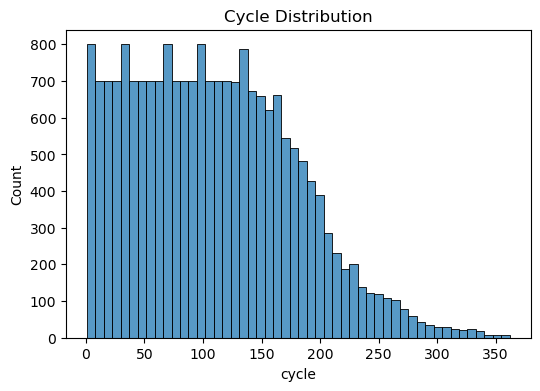

In [3]:
# data visualization
plt.figure(figsize=(6,4))
sns.histplot(train['cycle'], bins=50)
plt.title("Cycle Distribution")
plt.show()

In [4]:
# Creating RUL {Remaining Useful Life}
max_cycle = train.groupby('id')['cycle'].max().reset_index()
max_cycle.columns = ['id','max_cycle']

train = train.merge(max_cycle, on='id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

# RUL Cap
train['RUL'] = train['RUL'].clip(upper=125)
print("\nRUL Created Successfully")
print(train[['id','cycle','RUL']].head())


RUL Created Successfully
   id  cycle  RUL
0   1      1  125
1   1      2  125
2   1      3  125
3   1      4  125
4   1      5  125


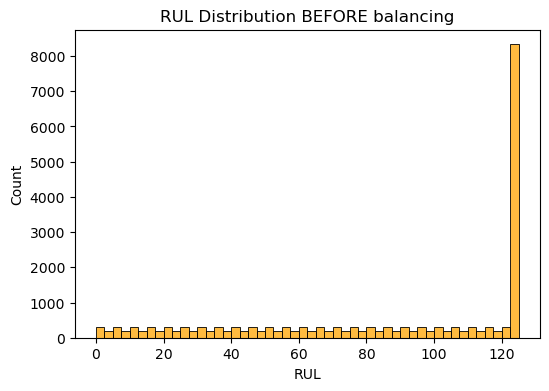

In [5]:
# RUL Distribution
plt.figure(figsize=(6,4))
sns.histplot(train['RUL'], bins=50, color='orange')
plt.title("RUL Distribution BEFORE balancing")
plt.show()

In [6]:
# Data cleaning (removing flat sensor readings)
sensor_cols = [col for col in train.columns if col.startswith('s')]
sensor_std = train[sensor_cols].std()
#print("\nSensor Standard Deviations")
#print(sensor_std)

flat_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print("\nFlat Sensors Removed:", flat_sensors)
train.drop(columns=flat_sensors, inplace=True)


Flat Sensors Removed: ['setting1', 'setting2', 'setting3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']


In [7]:
# Save active sensors 
active_sensors = [col for col in train.columns if col.startswith('s')]
joblib.dump(active_sensors, "active_sensors.pkl")

['active_sensors.pkl']

In [8]:
# Feature Engineering
for col in active_sensors:
    train[col+"_mean"] = train.groupby('id')[col].rolling(10).mean().reset_index(0,drop=True)
    train[col+"_std"] = train.groupby('id')[col].rolling(10).std().reset_index(0,drop=True)
    train[col+"_diff"] = train.groupby('id')[col].diff()

# Fill missing values
train.bfill(inplace=True)

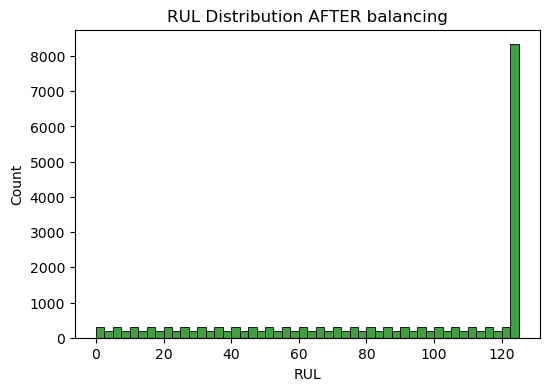

In [9]:
# RUL after balancing
plt.figure(figsize=(6,4))
sns.histplot(train['RUL'], bins=50, color='green')
plt.title("RUL Distribution AFTER balancing")
plt.show()

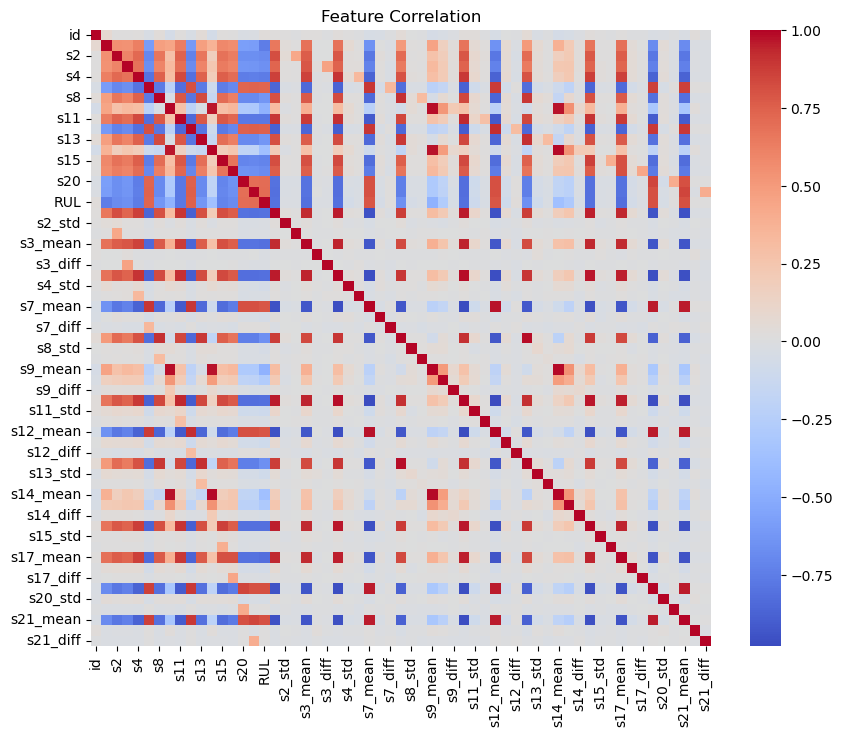

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [11]:
# Feature Selection
feature_cols = active_sensors + [col for col in train.columns if col.startswith('setting')]

X = train[feature_cols]
y = train['RUL']
groups = train['id']

print("Total Features:", len(feature_cols))

Total Features: 14


In [12]:
# Train-test split
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, val_idx in gss.split(X, y, groups):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [14]:
# Random Forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_val_scaled)

print("\n--- Random Forest Performance ---")
print("MAE:", mean_absolute_error(y_val, rf_pred))
print("RMSE:", np.sqrt(np.mean((y_val - rf_pred)**2)))
print("R2:", r2_score(y_val, rf_pred))


--- Random Forest Performance ---
MAE: 12.425418604939988
RMSE: 17.0872779652017
R2: 0.832217149579464


In [15]:
# XGBoost model
param_grid = {
    "n_estimators": [500, 700, 900],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.8, 0.85, 0.9],
    "colsample_bytree": [0.8, 0.85, 0.9]
}
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator = xgb_base,
    param_distributions = param_grid,
    n_iter = 10,
    scoring = 'neg_mean_absolute_error',
    cv = 3,
    verbose = 1, 
    random_state = 42,
    n_jobs = -1
)
random_search.fit(X_train_scaled, y_train)
print("\nBest Parameters:", random_search.best_params_)

#Final XGBoost Model
xgb_model =  random_search.best_estimator_
xgb_pred = xgb_model.predict(X_val_scaled)

print("\n--- XGBoost (Tuned) ---")
print("MAE:", mean_absolute_error(y_val, xgb_pred))
print("RMSE:", np.sqrt(np.mean((y_val - xgb_pred)**2)))
print("R2:", r2_score(y_val, xgb_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters: {'subsample': 0.85, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

--- XGBoost (Tuned) ---
MAE: 12.14179801940918
RMSE: 16.807834864707836
R2: 0.8376600742340088


In [16]:
final_pred = xgb_pred

In [17]:
# Evaluation
print("\nFINAL MODEL PERFORMANCE")
print("MAE:", mean_absolute_error(y_val, final_pred))
print("RMSE:", np.sqrt(np.mean((y_val - final_pred)**2)))
print("R2:", r2_score(y_val, final_pred))


FINAL MODEL PERFORMANCE
MAE: 12.14179801940918
RMSE: 16.807834864707836
R2: 0.8376600742340088


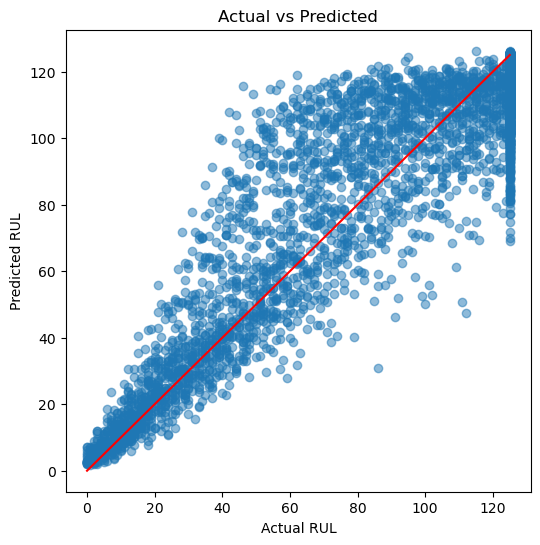

In [18]:
# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_val, final_pred, alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted")
plt.plot([0,125],[0,125], color='red')
plt.show()

In [19]:
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feature_cols, "feature_columns.pkl")
print("\nModels saved successfully!")


Models saved successfully!
